In [2]:
import pandas as pd
import praw
import os
from dotenv import load_dotenv
import re
import spacy
import pickle
from tensorflow.keras.models import load_model
from wordcloud import WordCloud

I0000 00:00:1776370677.111629   15210 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776370677.196860   15210 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776370679.514403   15210 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
load_dotenv()

reddit = praw.Reddit(
    client_id=os.getenv("CLIENT_ID"),
    client_secret=os.getenv("TOKEN_REDDIT"),
    user_agent=('sentiment_model_v2.keras')
)

# Test de connexion
print(reddit.read_only)

True


In [4]:
subreddit = reddit.subreddit('movies')

commentaires = []

# Récupère les 100 posts les plus récents
for post in subreddit.hot(limit=100):
    post.comments.replace_more(limit=0)  # charge tous les commentaires
    for comment in post.comments.list():
        commentaires.append({
            'post_title': post.title,
            'comment'   : comment.body,
            'score'     : comment.score,
            'date'      : comment.created_utc
        })


df_reddit = pd.DataFrame(commentaires)
print(f"{len(df_reddit):,} commentaires récupérés")
df_reddit.head()

13,809 commentaires récupérés


,post_title,comment,score,date
0,AMA/Q&A Announcement - Thomas Lennon - Tuesday...,"Actor, comedian, and screenwriter Thomas Lenno...",1,1.776014e+09
1,AMA/Q&A Announcement - Thomas Lennon - Tuesday...,[removed],62,1.776027e+09
2,AMA/Q&A Announcement - Thomas Lennon - Tuesday...,When are we going to get that The State reunio...,87,1.776014e+09
3,AMA/Q&A Announcement - Thomas Lennon - Tuesday...,we are forgetting his magnum opus out cold,41,1.776016e+09
4,AMA/Q&A Announcement - Thomas Lennon - Tuesday...,How do you get your massive junk into those li...,37,1.776015e+09


In [7]:
def clean_reddit(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)         # URLs
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)           # liens markdown [texte](url)
    text = re.sub(r'\*\*|__|\*|_|~~|`', '', text)        # formatage markdown
    text = re.sub(r'&gt;.*?\n', '', text)                # citations Reddit (>)
    text = re.sub(r'/r/\w+|/u/\w+', '', text)            # mentions subreddit/user
    text = re.sub(r'\n+', ' ', text)                     # sauts de ligne
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip().lower()     # espaces multiples
    return text
df_reddit['comment_clean'] = df_reddit['comment'].apply(clean_reddit)

In [8]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [9]:
processed = []
for doc in nlp.pipe(df_reddit['comment_clean'].tolist(), batch_size=500, n_process=-1):
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
        and len(token.text) > 1
    ]
    processed.append(' '.join(tokens))

df_reddit['comment_nlp'] = processed
df_reddit = df_reddit[df_reddit['comment_nlp'].str.len() > 0].reset_index(drop=True)
print(f"Après NLP : {len(df_reddit):,} commentaires")

Après NLP : 13,660 commentaires


In [13]:
with open('vectorizer_v2.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

model = load_model('sentiment_model_v2.keras')

In [14]:
X_reddit = vectorizer(df_reddit['comment_nlp'].values)
predictions = model.predict(X_reddit)

427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [16]:
df_reddit['score_sentiment'] = predictions
df_reddit['sentiment']       = (predictions > 0.5).astype(int)
df_reddit['sentiment_label'] = df_reddit['sentiment'].map({0: 'Négatif', 1: 'Positif'})

print(df_reddit[['comment', 'sentiment_label', 'score_sentiment']].head(10))

                                             comment sentiment_label  \
0  Actor, comedian, and screenwriter Thomas Lenno...         Positif   
1                                          [removed]         Négatif   
2  When are we going to get that The State reunio...         Positif   
3         we are forgetting his magnum opus out cold         Négatif   
4  How do you get your massive junk into those li...         Négatif   
5                      Don't forget I Love You, Man.         Positif   
6  How was kissing Paul Rudd in I Love You Man? D...         Positif   
7  how’d you get the role of Doctor in Dark Knigh...         Positif   
8  This man has zero limits on what he will do to...         Positif   
9                             Just new boot goofin'!         Positif   

   score_sentiment  
0         0.953286  
1         0.219403  
2         0.743892  
3         0.175054  
4         0.197639  
5         0.845342  
6         0.833083  
7         0.734744  
8         0.639194

In [17]:
print("=== TENDANCES GLOBALES ===")
print(df_reddit['sentiment_label'].value_counts())
print()
print(df_reddit['sentiment_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== TENDANCES GLOBALES ===
sentiment_label
Positif    8305
Négatif    5355
Name: count, dtype: int64

sentiment_label
Positif    60.8%
Négatif    39.2%
Name: proportion, dtype: str


In [18]:
df_reddit.to_csv("./asset/predict_comment_reddit_v2.csv")

In [26]:
# Top 10 posts par nb de commentaires + leur sentiment
top_posts = df_reddit.groupby('post_title').agg(
    total     = ('sentiment_label', 'count'),
    positifs  = ('sentiment_label', lambda x: (x == 'Positif').sum()),
    negatifs  = ('sentiment_label', lambda x: (x == 'Négatif').sum()),
).sort_values('total', ascending=False).head(10

=== TENDANCES GLOBALES ===
sentiment_label
Positif    8305
Négatif    5355
Name: count, dtype: int64

sentiment_label
Positif    60.8%
Négatif    39.2%
Name: proportion, dtype: str

=== TOP 10 POSTS ===
                                                    total  positifs  negatifs  \
post_title                                                                      
Which movie or TV "villain" did you completely ...    498       250       248   
Street Fighter | Official Trailer (2026 Movie)        496       355       141   
The film that disappointed you the most after m...    494       266       228   
Which Actor or Actress is a deal breaker for you?     486       282       204   
GODZILLA MINUS ZERO | First Official Teaser           482       309       173   
New poster for ‘Coyote vs. Acme.’ In theaters A...    481       315       166   
First Images from Ridley Scott's 'The Dog Stars...    478       298       180   
Steven Spielberg Warns Hollywood Must Invest in...    476       287 

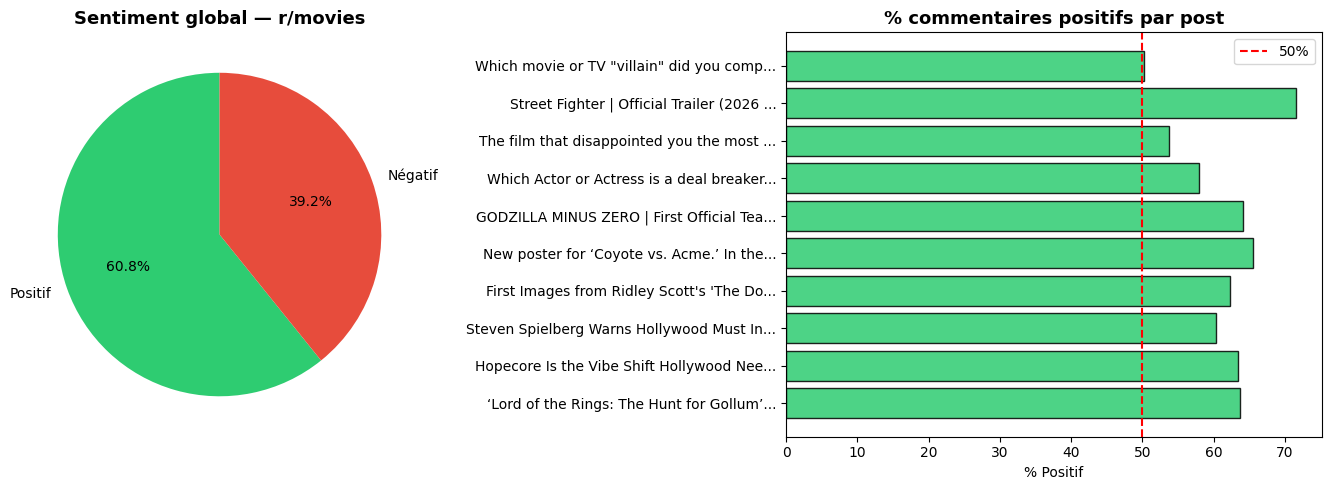

In [27]:

import matplotlib.pyplot as plt

# Distribution globale
print("=== TENDANCES GLOBALES ===")
counts = df_reddit['sentiment_label'].value_counts()
print(counts)
print()
print(df_reddit['sentiment_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart global
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Sentiment global — r/movies', fontsize=13, fontweight='bold')

# Top 10 posts par nb de commentaires + leur sentiment
top_posts = df_reddit.groupby('post_title').agg(
    total     = ('sentiment_label', 'count'),
    positifs  = ('sentiment_label', lambda x: (x == 'Positif').sum()),
    negatifs  = ('sentiment_label', lambda x: (x == 'Négatif').sum()),
).sort_values('total', ascending=False).head(10)

top_posts['ratio_positif'] = (top_posts['positifs'] / top_posts['total'] * 100).round(1)
print("\n=== TOP 10 POSTS ===")
print(top_posts)

# Barplot ratio positif par post
short_titles = [t[:40] + '...' for t in top_posts.index]
axes[1].barh(short_titles[::-1], top_posts['ratio_positif'][::-1],
             color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].axvline(x=50, color='red', linestyle='--', label='50%')
axes[1].set_title('% commentaires positifs par post', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% Positif')
axes[1].legend()

plt.tight_layout()
plt.savefig('analyse_reddit.png', dpi=150, bbox_inches='tight')
plt.show()

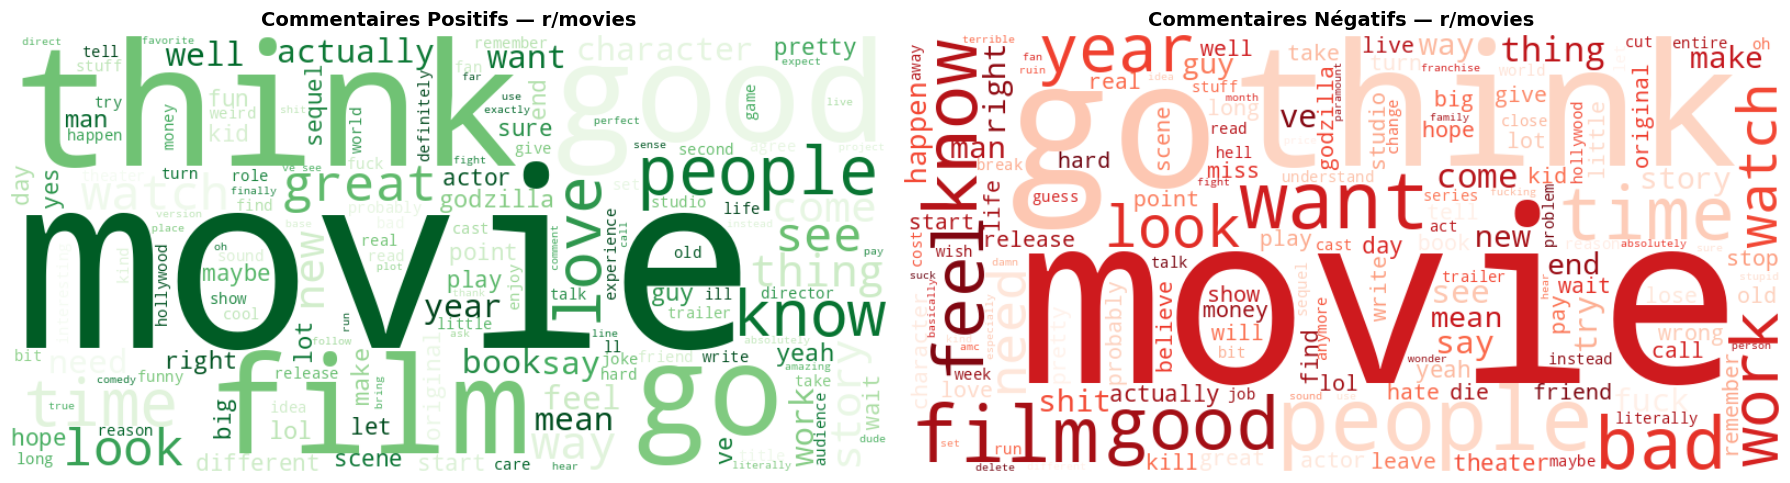

In [29]:
# Sépare les commentaires positifs et négatifs
positifs = ' '.join(df_reddit[df_reddit['sentiment_label'] == 'Positif']['comment_nlp'].astype(str))
negatifs = ' '.join(df_reddit[df_reddit['sentiment_label'] == 'Négatif']['comment_nlp'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Word Cloud Positif
wc_pos = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Greens').generate(positifs)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Commentaires Positifs — r/movies', fontsize=14, fontweight='bold')

# Word Cloud Négatif
wc_neg = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Reds').generate(negatifs)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Commentaires Négatifs — r/movies', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_reddit.png', dpi=150, bbox_inches='tight')
plt.show()

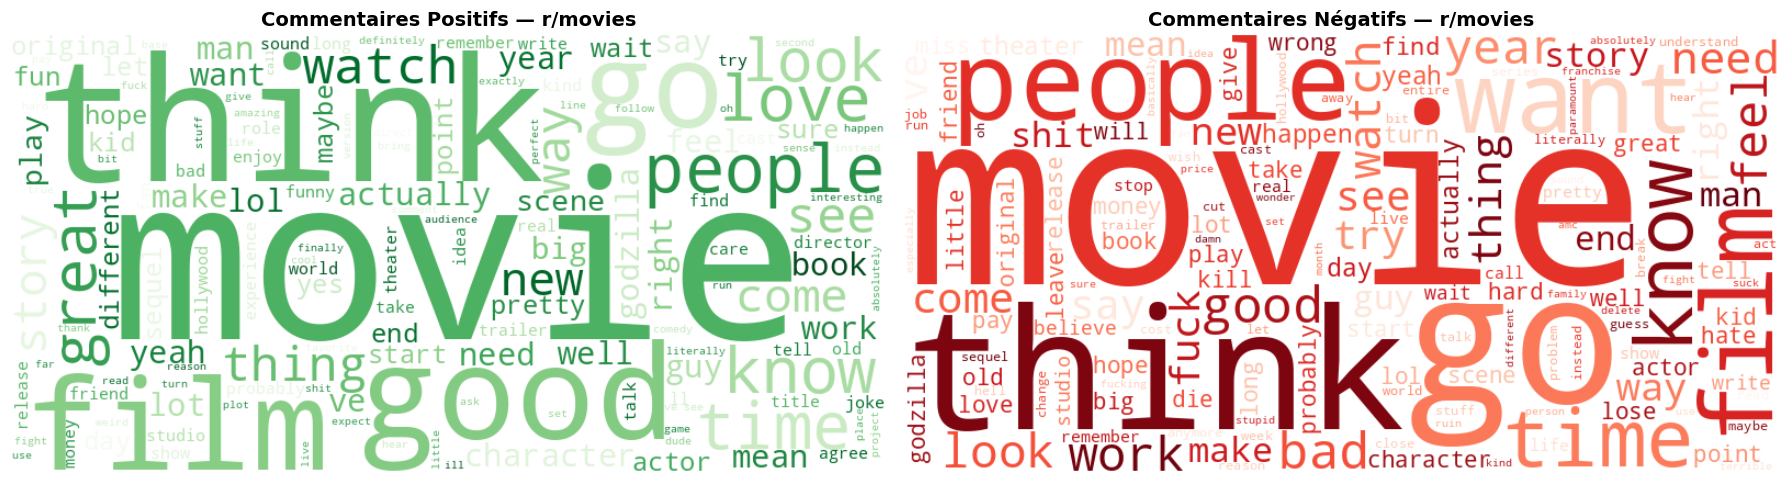

In [30]:
# Sépare les commentaires positifs et négatifs
positifs = ' '.join(df_reddit[df_reddit['sentiment_label'] == 'Positif']['comment_nlp'].astype(str))
negatifs = ' '.join(df_reddit[df_reddit['sentiment_label'] == 'Négatif']['comment_nlp'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Word Cloud Positif
wc_pos = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Greens').generate(positifs)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Commentaires Positifs — r/movies', fontsize=14, fontweight='bold')

# Word Cloud Négatif
wc_neg = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Reds').generate(negatifs)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Commentaires Négatifs — r/movies', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_reddit.png', dpi=150, bbox_inches='tight')
plt.show()

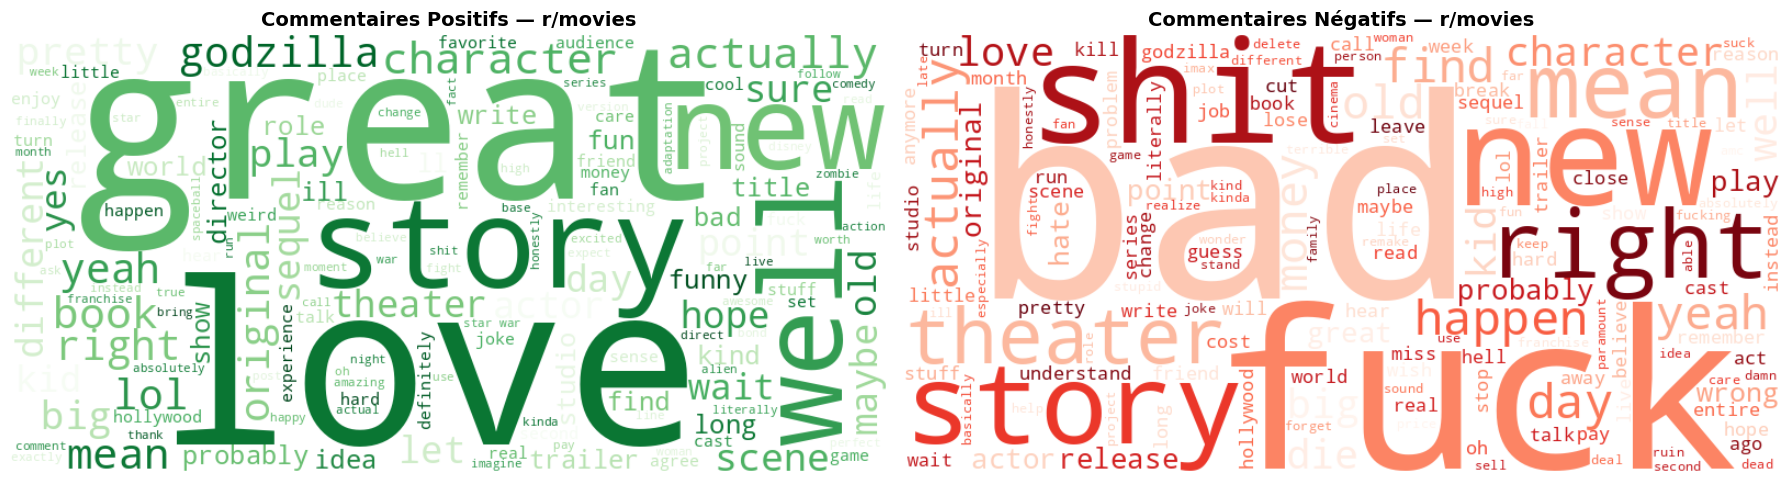

In [32]:
# Mots trop génériques à exclure
custom_stopwords = {
    'movie', 'film', 'think', 'go', 'know', 'want', 'say', 'make',
    'good', 'people', 'work', 'time', 'way', 'thing', 'look', 'come',
    'watch', 'see', 'feel', 'need', 'take', 'give', 'tell', 'try',
    'year', 'lot', 'bit', 'guy', 'man', 'end', 'start', 'like', 'get', 've'
}

def remove_custom_stopwords(text):
    return ' '.join([w for w in text.split() if w not in custom_stopwords])

positifs_filtered = remove_custom_stopwords(positifs)
negatifs_filtered = remove_custom_stopwords(negatifs)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_pos = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Greens').generate(positifs_filtered)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Commentaires Positifs — r/movies', fontsize=14, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Reds').generate(negatifs_filtered)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Commentaires Négatifs — r/movies', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_reddit_filtered.png', dpi=150, bbox_inches='tight')
plt.show()